In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import cv2

import os

#EDA
import matplotlib.pyplot as plt
import plotly_express as px
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#Data reading
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [2]:
Udataset = "/kaggle/input/tassie/upgrade_dataset"

Utraindata = os.path.join(Udataset, "train")
Utestdata = os.path.join(Udataset, "test")
Uvaldata = os.path.join(Udataset, "val")
UNtrain = os.path.join(Utraindata, "NORMAL")
UPtrain = os.path.join(Utraindata, "PNEUMONIA")
UNtest = os.path.join(Utestdata, "NORMAL")
UPtest = os.path.join(Utestdata, "PNEUMONIA")
UNval = os.path.join(Uvaldata, "NORMAL")
UPval = os.path.join(Uvaldata, "PNEUMONIA")



In [3]:
# Check if the dataset directories exist
if os.path.exists(Udataset):
    print("Dataset directory exists.")
else:
    print("Dataset directory does not exist.")

# Check the number of images in the train, test, and validation directories
print("Train Normal:", len(os.listdir(UNtrain)))
print("Train Pneumonia:", len(os.listdir(UPtrain)))
print("Test Normal:", len(os.listdir(UNtest)))
print("Test Pneumonia:", len(os.listdir(UPtest)))
print("Test Normal:", len(os.listdir(UNval)))
print("Test Pneumonia:", len(os.listdir(UPval)))


Dataset directory exists.
Train Normal: 1990
Train Pneumonia: 3100
Test Normal: 234
Test Pneumonia: 390
Test Normal: 505
Test Pneumonia: 783


***Training***

In [16]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard, LearningRateScheduler
from tensorflow.keras import layers, models

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Setup ImageDataGenerator for normalization and augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,  
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)  # Only rescaling for test data

# Training data generator
train_generator = train_datagen.flow_from_directory(
    Utraindata, 
    target_size=(299, 299),
    batch_size=32,
    class_mode='binary', 
    shuffle=True  
)

# Validation data generator
validation_generator = test_datagen.flow_from_directory(
    Uvaldata,  
    target_size=(299, 299),
    batch_size=32,
    class_mode='binary',
    shuffle=False 
)


Found 5090 images belonging to 2 classes.
Found 1288 images belonging to 2 classes.


In [18]:
# Constants
IMG_SIZE = (299, 299)
BATCH_SIZE = 64
EPOCHS = 20

In [19]:
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import InceptionV3

# Base InceptionV3 Model (without the top layers)
base_model = InceptionV3(include_top=False, weights='imagenet', input_shape=(299, 299, 3))

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers on top of the InceptionV3 base
x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dropout(0.5)(x)  # Dropout layer for regularization
output = layers.Dense(1, activation='sigmoid', kernel_regularizer=regularizers.l2(0.001))(x) 

# Create the final model
model = models.Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 299, 299, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_94 (Conv2D)        │ (None, 149, 149, 32)   │            864 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_94    │ (None, 149, 149, 32)   │             96 │ conv2d_94[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_94             │ (None, 149, 149, 32)   │              0 │ batch_normalization_9… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_95 (Conv2D)        │ (None, 147, 147, 32)   │          9,216 │ activation_94[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_95    │ (None, 147, 147, 32)   │             96 │ conv2d_95[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_95             │ (None, 147, 147, 32)   │              0 │ batch_normalization_9… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_96 (Conv2D)        │ (None, 147, 147, 64)   │         18,432 │ activation_95[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_96    │ (None, 147, 147, 64)   │            192 │ conv2d_96[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_96             │ (None, 147, 147, 64)   │              0 │ batch_normalization_9… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 73, 73, 64)     │              0 │ activation_96[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_97 (Conv2D)        │ (None, 73, 73, 80)     │          5,120 │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_97    │ (None, 73, 73, 80)     │            240 │ conv2d_97[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_97             │ (None, 73, 73, 80)     │              0 │ batch_normalization_9… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_98 (Conv2D)   

 Total params: 21,804,833 (83.18 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [20]:
def learning_rate_schedule(epoch, lr):
    if epoch % 10 == 0 and epoch != 0:
        lr = lr * 0.1 
    return lr
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipvalue=1.0),  
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [21]:
callbacks = [
    ModelCheckpoint('best_model.keras', monitor='val_loss', 
                    save_best_only=True, mode='min', verbose=1),
    EarlyStopping(monitor='val_loss', 
                  patience=5, 
                  restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', 
                      factor=0.2, 
                      patience=3, 
                      min_lr=1e-6),
    TensorBoard(log_dir='./logs', 
                histogram_freq=1),
    LearningRateScheduler(learning_rate_schedule)
]


In [22]:


class_weight = {0: 1.2828875045804324, 1: 0.8193306810203604}
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    class_weight=class_weight,
    callbacks=callbacks  
)


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 695ms/step - accuracy: 0.6393 - loss: 0.6429
Epoch 1: val_loss improved from inf to 0.56412, saving model to best_model.keras
160/160 ━━━━━━━━━━━━━━━━━━━━ 147s 821ms/step - accuracy: 0.6397 - loss: 0.6425 - val_accuracy: 0.7531 - val_loss: 0.5641 - learning_rate: 1.0000e-04
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.7941 - loss: 0.4628
Epoch 2: val_loss improved from 0.56412 to 0.54804, saving model to best_model.keras
160/160 ━━━━━━━━━━━━━━━━━━━━ 112s 672ms/step - accuracy: 0.7942 - loss: 0.4626 - val_accuracy: 0.7158 - val_loss: 0.5480 - learning_rate: 1.0000e-04
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.8388 - loss: 0.3966
Epoch 3: val_loss improved from 0.54804 to 0.51244, saving model to best_model.keras
160/160 ━━━━━━━━━━━━━━━━━━━━ 108s 647ms/step - accuracy: 0.8389 - loss: 0.3965 - val_accuracy: 0.7430 - val_loss: 0.5124 - learning_rate: 1.0000e-04
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/

41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step
Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.89      0.79      0.84       505
   PNEUMONIA       0.87      0.94      0.90       783

    accuracy                           0.88      1288
   macro avg       0.88      0.86      0.87      1288
weighted avg       0.88      0.88      0.88      1288



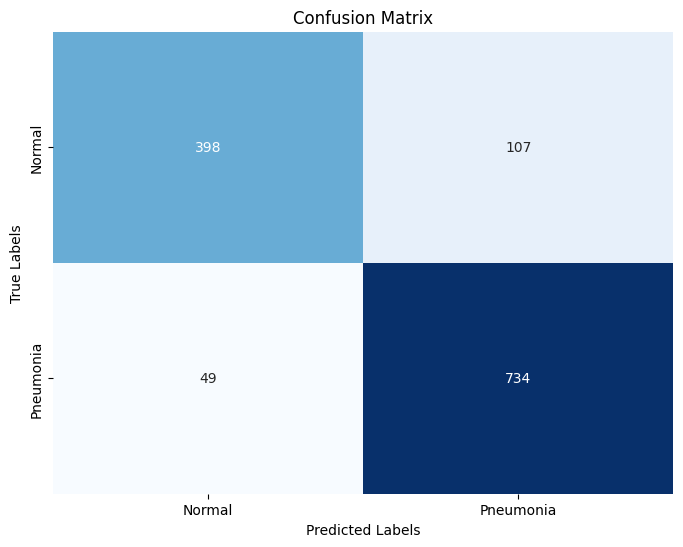

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions from the model (probabilities)
y_pred = model.predict(validation_generator)  
# Get the true labels (ground truth)
y_true = validation_generator.classes  

threshold = 0.2  # You can adjust this value as needed
y_pred_classes = (y_pred > threshold).astype(int)

# Generate classification report and confusion matrix
report = classification_report(y_true, y_pred_classes, target_names=['NORMAL', 'PNEUMONIA'])
print("Classification Report:")
print(report)

# Create confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, 
            xticklabels=["Normal", "Pneumonia"], yticklabels=["Normal", "Pneumonia"])

# Add labels and title
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()



In [26]:
# Save the entire model 
model.save('my_model.h5')  


In [27]:
# Unfreeze the top layers of the InceptionV3 base model
for layer in base_model.layers[-50:]: 
    layer.trainable = True

# Compile the model again with a very low learning rate for fine-tuning
model.compile(
    
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [28]:
# Continue training the model
fine_tune_epochs = 10  
total_epochs = EPOCHS + fine_tune_epochs

history_fine = model.fit(
    train_generator,
    epochs=total_epochs,
    initial_epoch=EPOCHS,  
    validation_data=validation_generator,
    callbacks=callbacks
) 

Epoch 21/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.8598 - loss: 0.3694
Epoch 21: val_loss did not improve from 0.41147
160/160 ━━━━━━━━━━━━━━━━━━━━ 141s 742ms/step - accuracy: 0.8598 - loss: 0.3693 - val_accuracy: 0.8175 - val_loss: 0.4437 - learning_rate: 1.0000e-06
Epoch 22/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.8815 - loss: 0.3228
Epoch 22: val_loss did not improve from 0.41147
160/160 ━━━━━━━━━━━━━━━━━━━━ 107s 640ms/step - accuracy: 0.8815 - loss: 0.3228 - val_accuracy: 0.8160 - val_loss: 0.4469 - learning_rate: 1.0000e-06
Epoch 23/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.8916 - loss: 0.3023
Epoch 23: val_loss did not improve from 0.41147
160/160 ━━━━━━━━━━━━━━━━━━━━ 107s 644ms/step - accuracy: 0.8917 - loss: 0.3023 - val_accuracy: 0.8137 - val_loss: 0.4375 - learning_rate: 1.0000e-06
Epoch 24/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.8933 - loss: 0.2839
Epoch 24: val_loss did not improve from 0.41147
160/1

41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 254ms/step
Confusion Matrix:
 [[494  11]
 [162 621]]
Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.75      0.98      0.85       505
   PNEUMONIA       0.98      0.79      0.88       783

    accuracy                           0.87      1288
   macro avg       0.87      0.89      0.86      1288
weighted avg       0.89      0.87      0.87      1288



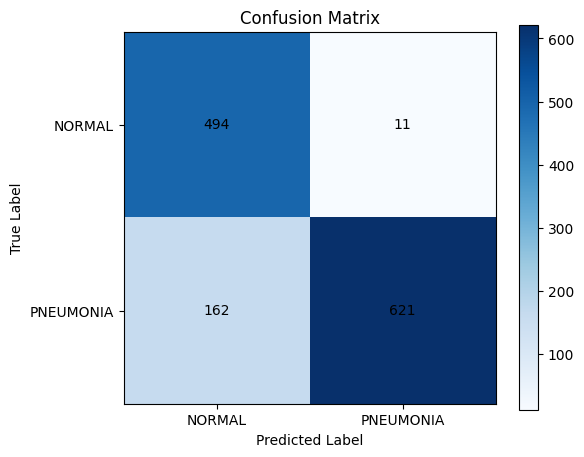

In [29]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt

# Predict on validation set
y_true = validation_generator.classes
y_pred = (model.predict(validation_generator) > 0.5).astype("int32")

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Classification Report
report = classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA'])
print("Classification Report:\n", report)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(conf_matrix, cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0, 1], ['NORMAL', 'PNEUMONIA'])
plt.yticks([0, 1], ['NORMAL', 'PNEUMONIA'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(conf_matrix[i, j]), ha='center', va='center', color='black')

plt.show()


SyntaxError: unmatched ')' (<ipython-input-30-fe2386b788d8>, line 9)